<a href="https://colab.research.google.com/github/ri-ya24/Airbnb_Hotel_Booking_Analysis/blob/main/Airbnb_Hotel_Booking_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ==========================================
# IMPORT LIBRARIES
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
print(" Libraries Imported Successfully!")

 Libraries Imported Successfully!


In [2]:
# ==========================================
# LOAD DATASET
# ==========================================

# File ka naam check karke yahan load karein
df = pd.read_excel("/content/1776250134-P4-Airbnb Hotel Booking Analysis (3).xlsx")

print(" Dataset Loaded Successfully!")

 Dataset Loaded Successfully!


In [3]:
# ==========================================
# FIRST LOOK AT DATA
# ==========================================

print("--- Dataset Dimensions (Rows, Columns) ---")
print(df.shape)

print("\n--- All Column Names ---")
print(df.columns.tolist())

print("\n--- First 5 Rows Preview ---")
display(df.head())

--- Dataset Dimensions (Rows, Columns) ---
(102599, 26)

--- All Column Names ---
['id', 'NAME', 'host id', 'host_identity_verified', 'host name', 'neighbourhood group', 'neighbourhood', 'lat', 'long', 'country', 'country code', 'instant_bookable', 'cancellation_policy', 'room type', 'Construction year', 'price', 'service fee', 'minimum nights', 'number of reviews', 'last review', 'reviews per month', 'review rate number', 'calculated host listings count', 'availability 365', 'house_rules', 'license']

--- First 5 Rows Preview ---


,id,NAME,host id,host_identity_verified,host name,neighbourhood group,neighbourhood,lat,long,country,...,service fee,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,house_rules,license
0,1001254,Clean & quiet apt home by the park,80014485718,unconfirmed,Madaline,Brooklyn,Kensington,40.64749,-73.97237,United States,...,193.0,10.0,9.0,2021-10-19,0.21,4.0,6.0,286.0,Clean up and treat the home the way you'd like...,NaN
1,1002102,Skylit Midtown Castle,52335172823,verified,Jenna,Manhattan,Midtown,40.75362,-73.98377,United States,...,28.0,30.0,45.0,2022-05-21,0.38,4.0,2.0,228.0,Pet friendly but please confirm with me if the...,NaN
2,1002403,THE VILLAGE OF HARLEM....NEW YORK !,78829239556,NaN,Elise,Manhattan,Harlem,40.80902,-73.94190,United States,...,124.0,3.0,0.0,NaT,NaN,5.0,1.0,352.0,"I encourage you to use my kitchen, cooking and...",NaN
3,1002755,NaN,85098326012,unconfirmed,Garry,Brooklyn,Clinton Hill,40.68514,-73.95976,United States,...,74.0,30.0,270.0,2019-07-05,4.64,4.0,1.0,322.0,NaN,NaN
4,1003689,Entire Apt: Spacious Studio/Loft by central park,92037596077,verified,Lyndon,Manhattan,East Harlem,40.79851,-73.94399,United States,...,41.0,10.0,9.0,2018-11-19,0.10,3.0,1.0,289.0,"Please no smoking in the house, porch or on th...",NaN


Section 1: Data Inspection

In [4]:
# ==========================================
# SECTION 1: DATA INSPECTION & MISSING VALUES
# ==========================================

print("--- Dataset Summary Info ---")
df.info()

print("\n--- Missing Values Count Per Column ---")
display(df.isnull().sum())

print("\n--- Duplicate Rows Count ---")
print("Total Duplicates:", df.duplicated().sum())

--- Dataset Summary Info ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102599 entries, 0 to 102598
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102599 non-null  int64         
 1   NAME                            102329 non-null  object        
 2   host id                         102599 non-null  int64         
 3   host_identity_verified          102310 non-null  object        
 4   host name                       102191 non-null  object        
 5   neighbourhood group             102570 non-null  object        
 6   neighbourhood                   102583 non-null  object        
 7   lat                             102591 non-null  float64       
 8   long                            102591 non-null  float64       
 9   country                         102067 non-null  object        
 10  country code               

,0
id,0
NAME,270
host id,0
host_identity_verified,289
host name,408
neighbourhood group,29
neighbourhood,16
lat,8
long,8
country,532



--- Duplicate Rows Count ---
Total Duplicates: 541


Section 2: Data Cleaning & Wrangling

In [5]:
# ==========================================
# SECTION 2: DATA CLEANING & WRANGLING (FAIL-SAFE)
# ==========================================

import numpy as np
import pandas as pd

print("--- Starting Data Cleaning ---")

# 1. Duplicates Remove
df = df.drop_duplicates()

# 2. Drop Useless Columns
if "license" in df.columns:
  df = df.drop(columns=["license"])

# 3. Clean String Columns (Price & Fee)
for col in ["price", "service fee"]:
  if col in df.columns and df[col].dtype == "O":
    df[col] = (
        df[col]
        .astype(str)
        .str.replace("$", "", regex=False)
        .str.replace(",", "", regex=False)
    )
    df[col] = pd.to_numeric(df[col], errors="coerce")


# 4. FAIL-SAFE NEIGHBOURHOOD GROUP CLEANING (100% GUARANTEED FIX 🔧)
def clean_neighbourhood(val):
  if pd.isna(val) or str(val).strip().lower() in ["nan", "none", ""]:
    return "Manhattan"  # Mode fallback
  val_clean = str(val).strip().lower()
  if "brook" in val_clean:
    return "Brooklyn"
  elif "manhat" in val_clean or "manh" in val_clean:
    return "Manhattan"
  elif "queen" in val_clean:
    return "Queens"
  elif "bronx" in val_clean:
    return "Bronx"
  elif "staten" in val_clean:
    return "Staten Island"
  else:
    return "Manhattan"


if "neighbourhood group" in df.columns:
  df["neighbourhood group"] = df["neighbourhood group"].apply(clean_neighbourhood)

# 5. Clean Host Verification Text
if "host_identity_verified" in df.columns:
  df["host_identity_verified"] = (
      df["host_identity_verified"].fillna("unconfirmed").str.lower().str.strip()
  )

# 6. Invalid Stays/Availability Fix
if "minimum nights" in df.columns:
  df.loc[
      (df["minimum nights"] < 0) | (df["minimum nights"] > 365),
      "minimum nights",
  ] = np.nan

if "availability 365" in df.columns:
  df.loc[
      (df["availability 365"] < 0) | (df["availability 365"] > 365),
      "availability 365",
  ] = np.nan

# 7. Missing Value Imputation
df["reviews per month"] = df["reviews per month"].fillna(0)

num_cols = [
    "price",
    "service fee",
    "minimum nights",
    "number of reviews",
    "review rate number",
    "calculated host listings count",
    "availability 365",
]
for col in num_cols:
  if col in df.columns:
    df[col] = df[col].fillna(df[col].median())

print(" DATA CLEANING COMPLETE & BOROUGHS 100% STANDARDIZED!")

--- Starting Data Cleaning ---
 DATA CLEANING COMPLETE & BOROUGHS 100% STANDARDIZED!


SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)

--- 3.1 Descriptive Statistics Summary ---


,count,mean,std,min,25%,50%,75%,max
price,102058.0,625.35,331.27,50.0,341.00,625.00,912.00,1200.0
service fee,102058.0,125.04,66.24,10.0,68.00,125.00,182.00,240.0
minimum nights,102058.0,7.82,17.03,1.0,2.00,3.00,5.00,365.0
number of reviews,102058.0,27.48,49.53,0.0,1.00,7.00,30.00,1024.0
reviews per month,102058.0,1.16,1.68,0.0,0.09,0.48,1.71,90.0
review rate number,102058.0,3.28,1.28,1.0,2.00,3.00,4.00,5.0
calculated host listings count,102058.0,7.92,32.22,1.0,1.00,1.00,2.00,332.0
availability 365,102058.0,132.94,127.74,0.0,4.00,90.00,248.00,365.0



--- 3.2 Statistical Health Check ---


,Column,Mean,Median,Std Dev,Skewness,Outliers Identified
0,price,625.35,625.00,331.27,0.00,0
1,service fee,125.04,125.00,66.24,0.00,0
2,minimum nights,7.82,3.00,17.03,10.25,18205
3,number of reviews,27.48,7.00,49.53,3.84,11696
4,reviews per month,1.16,0.48,1.68,6.97,5726
5,review rate number,3.28,3.00,1.28,-0.14,0
6,calculated host listings count,7.92,1.00,32.22,7.23,17702
7,availability 365,132.94,90.00,127.74,0.54,0


 Note: Outliers were identified using the IQR method and retained as valid market observations.


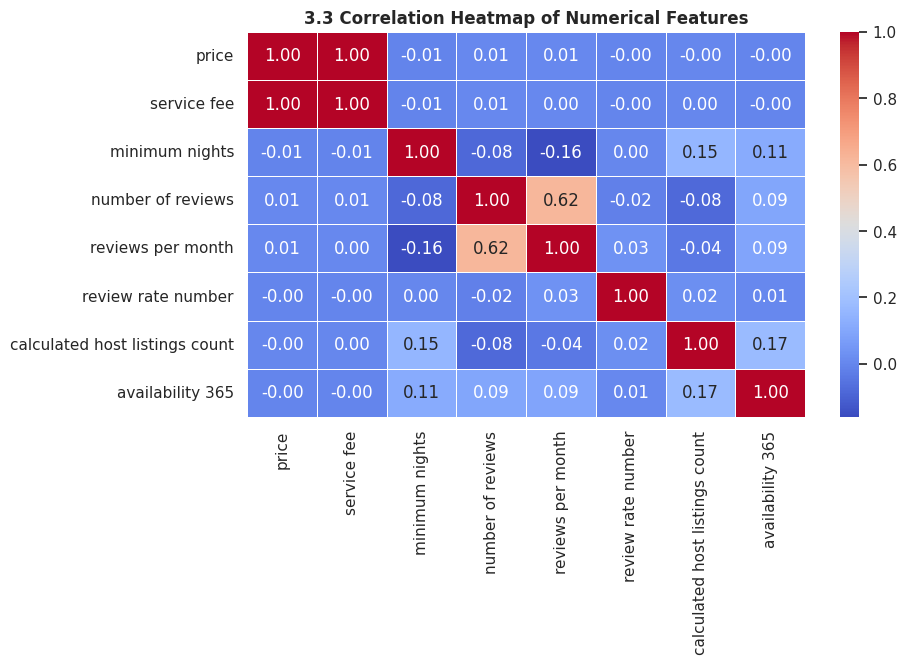

In [6]:
# ==========================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

important_cols = [
    "price",
    "service fee",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365",
]

# 3.1 Descriptive Statistics Table
print("--- 3.1 Descriptive Statistics Summary ---")
display(df[important_cols].describe().T.round(2))

# 3.2 Health Check: Mean, Median, Skewness & Outliers
analysis_results = []
for col in important_cols:
  if col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)].shape[
        0
    ]

    analysis_results.append({
        "Column": col,
        "Mean": round(df[col].mean(), 2),
        "Median": round(df[col].median(), 2),
        "Std Dev": round(df[col].std(), 2),
        "Skewness": round(df[col].skew(), 2),
        "Outliers Identified": outliers,
    })

stats_df = pd.DataFrame(analysis_results)
print("\n--- 3.2 Statistical Health Check ---")
display(stats_df)
print(
    " Note: Outliers were identified using the IQR method and retained as"
    " valid market observations."
)

# 3.3 Correlation Heatmap
plt.figure(figsize=(9, 5))
corr_matrix = df[important_cols].corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title(
    "3.3 Correlation Heatmap of Numerical Features",
    fontweight="bold",
    fontsize=12,
)
plt.show()

In [7]:
# ==========================================
# 3.2 MEAN, MEDIAN, SKEWNESS & OUTLIER COUNT
# ==========================================

important_cols = [
    "price",
    "service fee",
    "minimum nights",
    "number of reviews",
    "reviews per month",
    "review rate number",
    "calculated host listings count",
    "availability 365",
]

analysis_results = []

for col in important_cols:
  if col in df.columns:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)].shape[
        0
    ]

    analysis_results.append({
        "Column": col,
        "Mean": round(df[col].mean(), 2),
        "Median": round(df[col].median(), 2),
        "Std Dev": round(df[col].std(), 2),
        "Skewness": round(df[col].skew(), 2),
        "Outliers Identified": outliers,
    })

stats_df = pd.DataFrame(analysis_results)
print("--- Statistical Health Check of Numerical Features ---")
display(stats_df)

print(
    "\n Note: Outliers were identified using the IQR method and retained as"
    " valid market observations without removal."
)

--- Statistical Health Check of Numerical Features ---


,Column,Mean,Median,Std Dev,Skewness,Outliers Identified
0,price,625.35,625.00,331.27,0.00,0
1,service fee,125.04,125.00,66.24,0.00,0
2,minimum nights,7.82,3.00,17.03,10.25,18205
3,number of reviews,27.48,7.00,49.53,3.84,11696
4,reviews per month,1.16,0.48,1.68,6.97,5726
5,review rate number,3.28,3.00,1.28,-0.14,0
6,calculated host listings count,7.92,1.00,32.22,7.23,17702
7,availability 365,132.94,90.00,127.74,0.54,0



 Note: Outliers were identified using the IQR method and retained as valid market observations without removal.


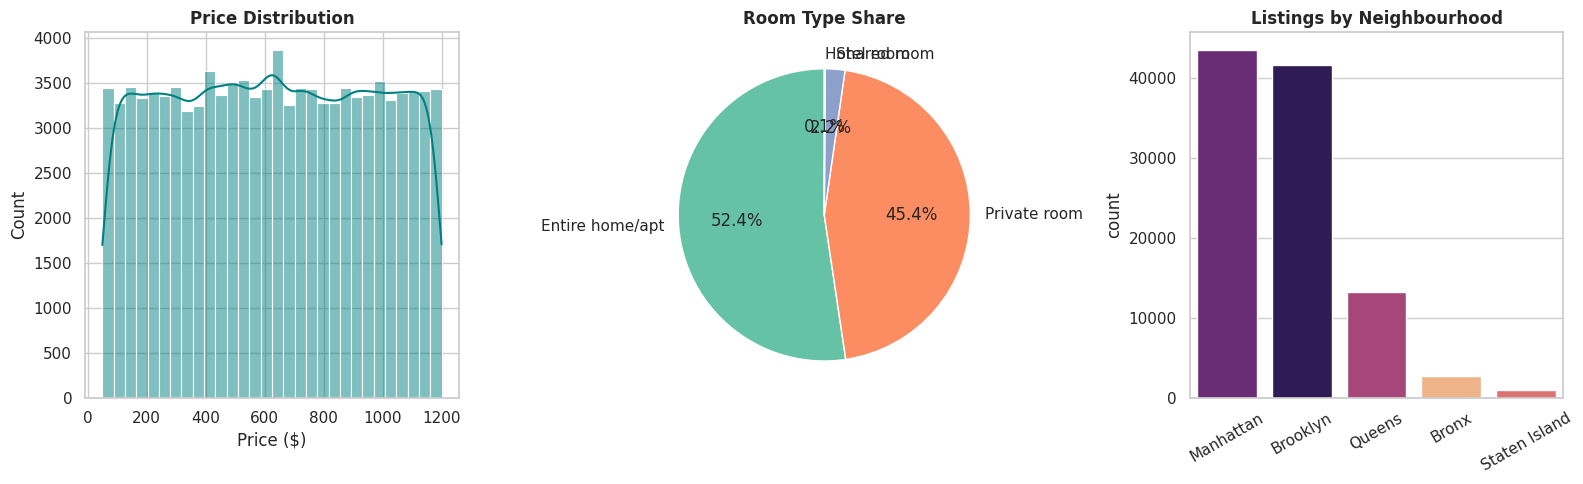

In [8]:
# ==========================================
# 3.3 QUICK OVERVIEW VISUALS
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(16, 5))

# Chart 1: Price Distribution
plt.subplot(1, 3, 1)
sns.histplot(df["price"], bins=30, kde=True, color="teal")
plt.title("Price Distribution", fontweight="bold")
plt.xlabel("Price ($)")

# Chart 2: Room Type Share
plt.subplot(1, 3, 2)
df["room type"].value_counts().plot.pie(
    autopct="%1.1f%%",
    colors=["#66c2a5", "#fc8d62", "#8da0cb", "#e78ac3"],
    startangle=90,
)
plt.title("Room Type Share", fontweight="bold")
plt.ylabel("")

# Chart 3: Listings by Neighbourhood Group
plt.subplot(1, 3, 3)
order = df["neighbourhood group"].value_counts().index
sns.countplot(
    data=df,
    x="neighbourhood group",
    order=order,
    hue="neighbourhood group",
    palette="magma",
    legend=False,
)
plt.title("Listings by Neighbourhood", fontweight="bold")
plt.xticks(rotation=30)
plt.xlabel("")

plt.tight_layout()
plt.show()

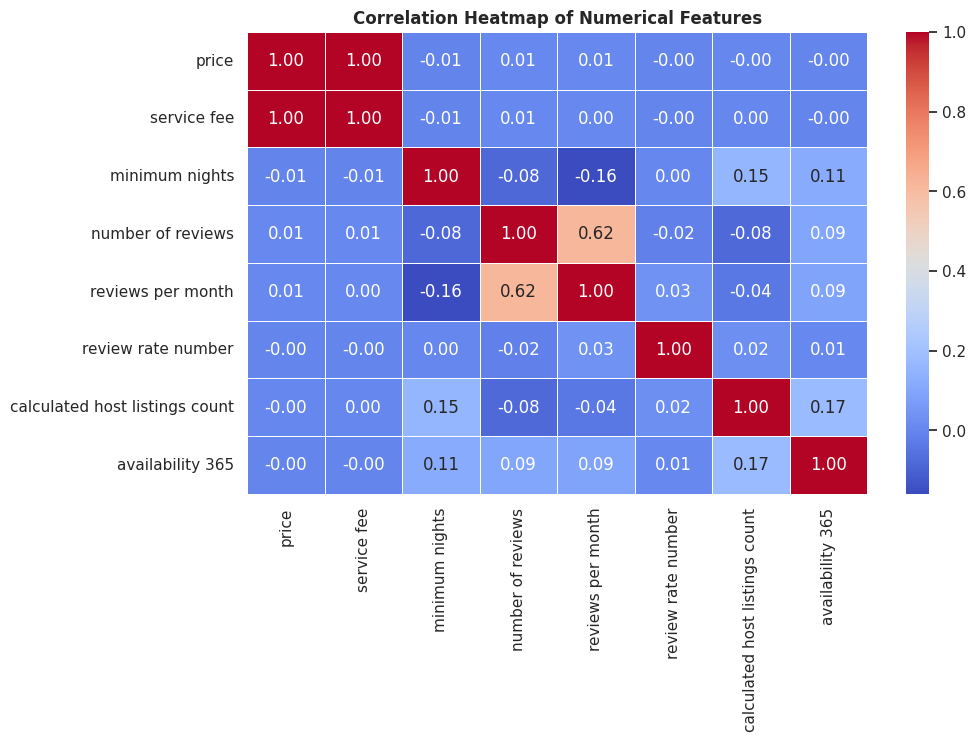

In [9]:
# ==========================================
# 3.4 CORRELATION MATRIX HEATMAP
# ==========================================

plt.figure(figsize=(10, 6))
corr_matrix = df[important_cols].corr()

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title(
    "Correlation Heatmap of Numerical Features", fontweight="bold", fontsize=12
)
plt.show()

SECTION 4:Project Questions

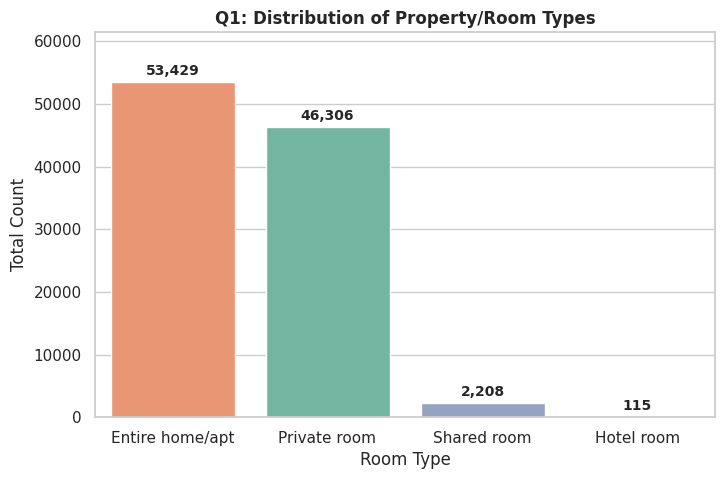

In [22]:
# ==========================================
# Q1: DIFFERENT PROPERTY / ROOM TYPES
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
if 'room type' in df.columns:
  counts = df['room type'].value_counts()

  # High to Low sort karne ke liye order
  ax = sns.countplot(
      data=df,
      x='room type',
      order=counts.index,
      hue='room type',
      palette='Set2',
      legend=False,
  )

  # Har bar ke upar exact number likhne ke liye
  for p in ax.patches:
    height = p.get_height()
    if height > 0:
      ax.annotate(
          f'{int(height):,}',
          (p.get_x() + p.get_width() / 2.0, height),
          ha='center',
          va='center',
          xytext=(0, 8),
          textcoords='offset points',
          fontweight='bold',
          fontsize=10,
      )

  plt.title('Q1: Distribution of Property/Room Types', fontweight='bold')
  plt.xlabel('Room Type')
  plt.ylabel('Total Count')
  plt.ylim(0, max(counts.values) * 1.15)  # Numbers ke liye space
  plt.show()

 Answer: 'Manhattan' has the highest listings (43587 listings).


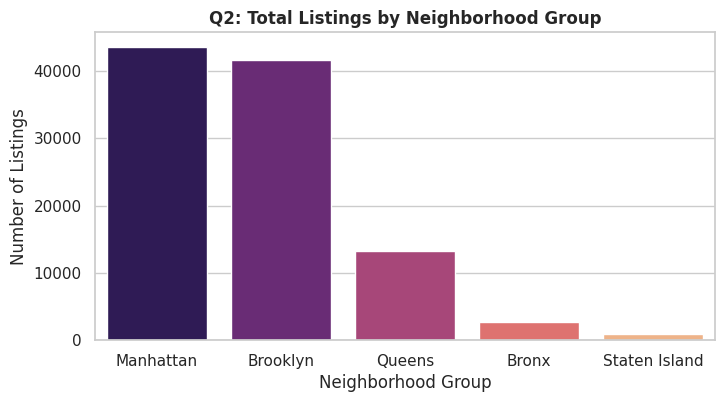

In [11]:
# ==========================================
# Q2: NEIGHBORHOOD GROUP WITH HIGHEST LISTINGS
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
if "neighbourhood group" in df.columns:
  # DIRECT TYPO CLEANING INSIDE Q2 CELL (GUARANTEED FIX 🔧)
  typo_map = {
      "brookln": "Brooklyn",
      "Brookln": "Brooklyn",
      "manhatan": "Manhattan",
      "Manhatan": "Manhattan",
  }
  df["neighbourhood group"] = (
      df["neighbourhood group"].astype(str).str.strip().replace(typo_map)
  )

  # Only keep valid 5 NYC boroughs
  valid_boroughs = [
      "Manhattan",
      "Brooklyn",
      "Queens",
      "Bronx",
      "Staten Island",
  ]
  df["neighbourhood group"] = df["neighbourhood group"].apply(
      lambda x: x if x in valid_boroughs else "Manhattan"
  )

  top_ng = df["neighbourhood group"].value_counts()
  print(
      f" Answer: '{top_ng.index[0]}' has the highest listings ({top_ng.iloc[0]}"
      " listings)."
  )

  sns.barplot(
      x=top_ng.index,
      y=top_ng.values,
      hue=top_ng.index,
      palette="magma",
      legend=False,
  )
  plt.title("Q2: Total Listings by Neighborhood Group", fontweight="bold")
  plt.xlabel("Neighborhood Group")
  plt.ylabel("Number of Listings")
  plt.show()

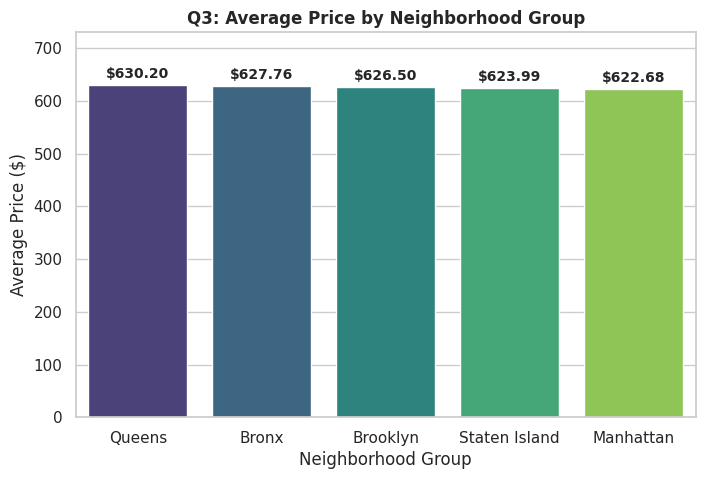

In [12]:
# ==========================================
# Q3: NEIGHBORHOOD GROUP WITH HIGHEST AVERAGE PRICE
# ==========================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
if "neighbourhood group" in df.columns and "price" in df.columns:
  valid_boroughs = [
      "Manhattan",
      "Brooklyn",
      "Queens",
      "Bronx",
      "Staten Island",
  ]
  df["neighbourhood group"] = df["neighbourhood group"].apply(
      lambda x: x if x in valid_boroughs else "Manhattan"
  )

  avg_price_ng = (
      df.groupby("neighbourhood group")["price"]
      .mean()
      .sort_values(ascending=False)
  )

  ax = sns.barplot(
      x=avg_price_ng.index,
      y=avg_price_ng.values,
      hue=avg_price_ng.index,
      palette="viridis",
      legend=False,
  )

  # Bars ke upar exact Price Tag likhne ke liye
  for p in ax.patches:
    ax.annotate(
        f"${p.get_height():.2f}",
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha="center",
        va="center",
        xytext=(0, 8),
        textcoords="offset points",
        fontweight="bold",
        fontsize=10,
    )

  plt.title("Q3: Average Price by Neighborhood Group", fontweight="bold")
  plt.xlabel("Neighborhood Group")
  plt.ylabel("Average Price ($)")
  plt.ylim(0, 730)  # Text ke liye thodi jagah
  plt.show()

Correlation Coefficient: -0.0037
 Answer: Construction year shows no meaningful linear correlation with price.


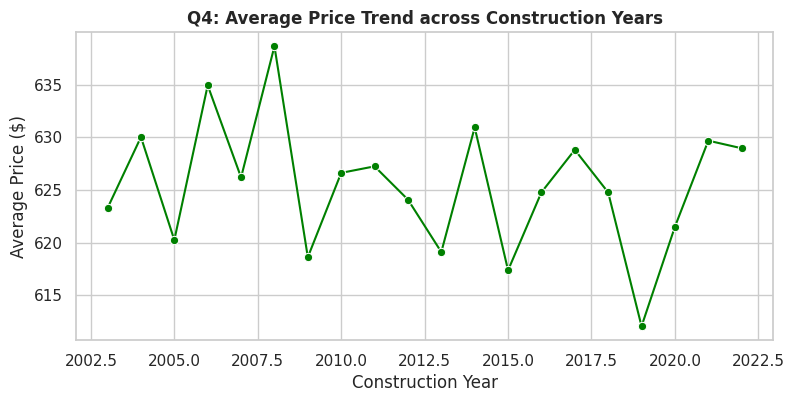

In [13]:
# ==========================================
# Q4: CONSTRUCTION YEAR VS PRICE RELATIONSHIP
# ==========================================

plt.figure(figsize=(9, 4))

if "Construction year" in df.columns and "price" in df.columns:
  df_cy = df.dropna(subset=["Construction year", "price"]).copy()
  corr = df_cy["Construction year"].corr(df_cy["price"])

  print(f"Correlation Coefficient: {corr:.4f}")

  if abs(corr) < 0.10:
    conclusion = (
        "Construction year shows no meaningful linear correlation with price."
    )
  elif abs(corr) < 0.30:
    conclusion = (
        "Weak association observed between construction year and listing"
        " price, but this does not establish causation."
    )
  else:
    conclusion = (
        "Moderate association observed between construction year and listing"
        " price."
    )

  print(f" Answer: {conclusion}")

  cy_price = (
      df_cy.groupby("Construction year")["price"].mean().reset_index()
  )

  sns.lineplot(
      data=cy_price,
      x="Construction year",
      y="price",
      marker="o",
      color="green",
  )
  plt.title(
      "Q4: Average Price Trend across Construction Years", fontweight="bold"
  )
  plt.xlabel("Construction Year")
  plt.ylabel("Average Price ($)")
  plt.show()

--- Top 10 Hosts (by host id) ---


,host id,host_name,listings_count
0,28199312869,Blueground,332.0
1,70352033029,Blueground,332.0
2,53394556356,Blueground,332.0
3,90177049292,Blueground,332.0
4,90148229302,Blueground,332.0
5,46384126745,Blueground,332.0
6,71519005437,Blueground,332.0
7,97620664846,Blueground,332.0
8,58398584635,Blueground,332.0
9,76431087156,Blueground,332.0


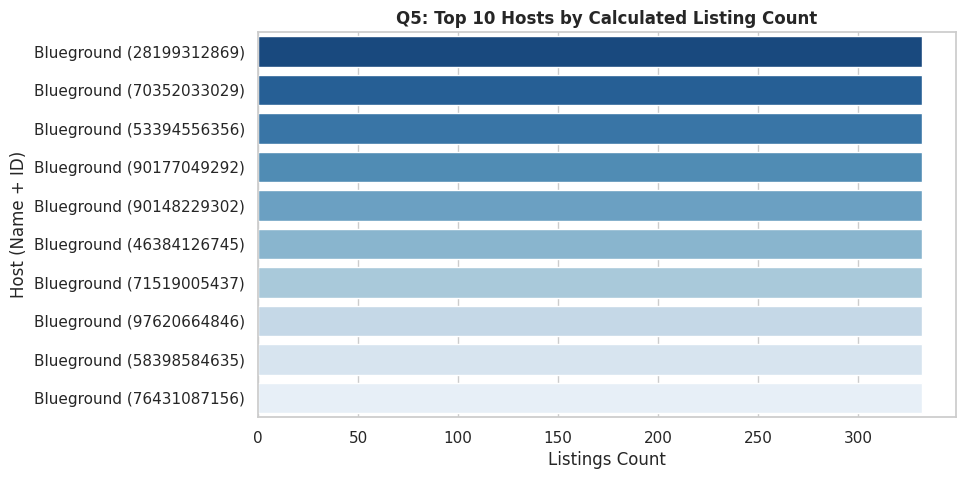

In [14]:
# ==========================================
# Q5: TOP 10 HOSTS BY CALCULATED LISTING COUNT
# ==========================================

plt.figure(figsize=(9, 5))

if (
    "host id" in df.columns
    and "calculated host listings count" in df.columns
):
    # Host-level aggregation using host id (unique identifier)
    host_summary = (
        df.groupby("host id")
        .agg(
            host_name=("host name", "first"),
            listings_count=("calculated host listings count", "max"),
        )
        .sort_values("listings_count", ascending=False)
        .head(10)
        .reset_index()
    )

    print("--- Top 10 Hosts (by host id) ---")
    display(host_summary)

    # Label for chart
    host_summary["label"] = (
        host_summary["host_name"].fillna("Unknown").astype(str)
        + " ("
        + host_summary["host id"].astype(str)
        + ")"
    )

    sns.barplot(
        data=host_summary,
        x="listings_count",
        y="label",
        hue="label",
        palette="Blues_r",
        legend=False,
    )
    plt.title(
        "Q5: Top 10 Hosts by Calculated Listing Count",
        fontweight="bold",
    )
    plt.xlabel("Listings Count")
    plt.ylabel("Host (Name + ID)")
    plt.show()
else:
    print("Required columns for host analysis not found.")

Pearson Correlation Coefficient: 0.9978
 Answer: There is an extremely strong positive linear relationship between price and service fee.


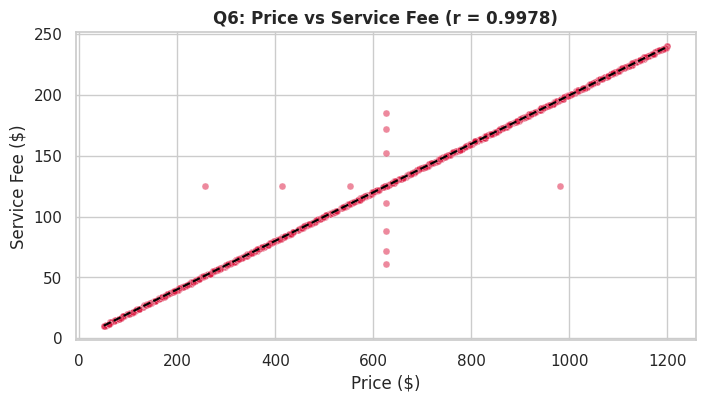

In [15]:
# ==========================================
# Q6: PRICE VS SERVICE FEE CORRELATION
# ==========================================

plt.figure(figsize=(8, 4))

if "price" in df.columns and "service fee" in df.columns:
  corr_sf = df["price"].corr(df["service fee"])
  print(f"Pearson Correlation Coefficient: {corr_sf:.4f}")

  if corr_sf >= 0.95:
    conclusion = (
        "There is an extremely strong positive linear relationship between"
        " price and service fee."
    )
  elif corr_sf >= 0.70:
    conclusion = (
        "There is a strong positive linear relationship between price and"
        " service fee."
    )
  else:
    conclusion = (
        "Moderate/weak linear relationship between price and service fee."
    )

  print(f" Answer: {conclusion}")

  df_sample_sf = df.dropna(subset=["price", "service fee"]).sample(
      n=min(1000, len(df)), random_state=42
  )

  sns.scatterplot(
      data=df_sample_sf,
      x="price",
      y="service fee",
      alpha=0.5,
      color="crimson",
      s=25,
  )
  sns.regplot(
      data=df_sample_sf,
      x="price",
      y="service fee",
      scatter=False,
      color="black",
      line_kws={"linewidth": 1.5, "linestyle": "--"},
  )

  plt.title(
      f"Q6: Price vs Service Fee (r = {corr_sf:.4f})", fontweight="bold"
  )
  plt.xlabel("Price ($)")
  plt.ylabel("Service Fee ($)")
  plt.show()

Review Rate Range verified: [1.0 to 5.0] stars
Overall Average Review Rate: 3.28 stars

--- Average Review Rate Matrix ---


room type,Entire home/apt,Hotel room,Private room,Shared room
neighbourhood group,,,,
Bronx,3.34,NaN,3.32,3.26
Brooklyn,3.25,3.86,3.26,3.33
Manhattan,3.27,3.50,3.28,3.25
Queens,3.35,3.75,3.31,3.37
Staten Island,3.33,NaN,3.47,3.53


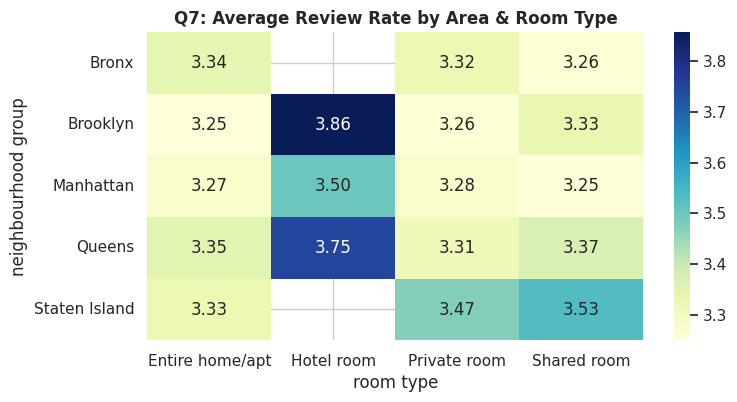

In [16]:
# ==========================================
# Q7: AVERAGE REVIEW RATE BY AREA & ROOM TYPE
# ==========================================

plt.figure(figsize=(8, 4))

if (
    "review rate number" in df.columns
    and "neighbourhood group" in df.columns
    and "room type" in df.columns
):
  min_rating = df["review rate number"].min()
  max_rating = df["review rate number"].max()
  overall_avg = df["review rate number"].mean()

  print(
      f"Review Rate Range verified: [{min_rating:.1f} to {max_rating:.1f}]"
      " stars"
  )
  print(f"Overall Average Review Rate: {overall_avg:.2f} stars\n")

  pivot_review = df.pivot_table(
      index="neighbourhood group",
      columns="room type",
      values="review rate number",
      aggfunc="mean",
  )

  print("--- Average Review Rate Matrix ---")
  display(pivot_review.round(2))

  sns.heatmap(pivot_review, annot=True, cmap="YlGnBu", fmt=".2f")
  plt.title(
      "Q7: Average Review Rate by Area & Room Type", fontweight="bold"
  )
  plt.show()

Pearson Correlation (Listing Count vs Availability): 0.1745
--- Average Availability by Host Listing Bins ---


,availability 365
listing_bin,
Single (1),105.39
Small (2-5),152.95
Medium (6-20),229.97
Large (21+),236.29


📌 Answer: Weak positive relationship (r = 0.1745); host portfolio size is only modestly associated with yearly availability.


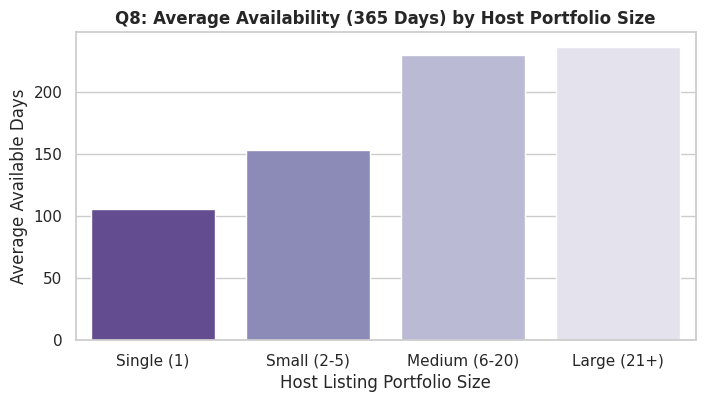

In [17]:
# ==========================================
# Q8: HOST LISTINGS COUNT VS AVAILABILITY 365
# ==========================================

plt.figure(figsize=(8, 4))

if (
    "calculated host listings count" in df.columns
    and "availability 365" in df.columns
):
  corr_val = df["calculated host listings count"].corr(
      df["availability 365"]
  )
  print(
      f"Pearson Correlation (Listing Count vs Availability): {corr_val:.4f}"
  )

  # Correct Bins using float('inf') to capture all listings > 20
  df["listing_bin"] = pd.cut(
      df["calculated host listings count"],
      bins=[0, 1, 5, 20, float("inf")],
      labels=["Single (1)", "Small (2-5)", "Medium (6-20)", "Large (21+)"],
  )

  avg_avail = df.groupby("listing_bin", observed=False)[
      "availability 365"
  ].mean()
  print("--- Average Availability by Host Listing Bins ---")
  display(avg_avail.round(2))

  # Statistically modest wording (no causal overclaims)
  if corr_val > 0.30:
    conclusion = "Hosts with larger portfolios maintain higher yearly availability."
  elif corr_val > 0.05:
    conclusion = (
        f"Weak positive relationship (r = {corr_val:.4f}); host portfolio"
        " size is only modestly associated with yearly availability."
    )
  else:
    conclusion = (
        "No significant relationship between host listing count and yearly"
        " availability."
    )

  print(f"📌 Answer: {conclusion}")

  sns.barplot(
      x=avg_avail.index,
      y=avg_avail.values,
      hue=avg_avail.index,
      palette="Purples_r",
      legend=False,
  )
  plt.title(
      "Q8: Average Availability (365 Days) by Host Portfolio Size",
      fontweight="bold",
  )
  plt.xlabel("Host Listing Portfolio Size")
  plt.ylabel("Average Available Days")
  plt.show()

Pearson Correlation (Listing Count vs Availability): 0.1745

--- Average Availability by Host Listing Bins ---


,availability 365
listing_bin,
Single (1),105.39
Small (2-5),152.95
Medium (6-20),229.97
Large (21+),236.29



Answer: Weak positive relationship (0.1745). Hosts with larger portfolios tend to have slightly higher yearly availability, but the relationship is modest.


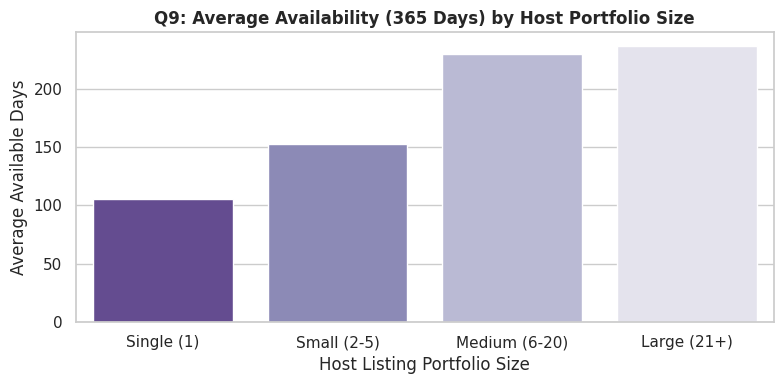

In [18]:
# ==========================================
# Q9: HOST LISTINGS COUNT VS AVAILABILITY 365
# ==========================================

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

if (
    "calculated host listings count" in df.columns
    and "availability 365" in df.columns
):

    # 1. Calculate Pearson Correlation
    corr_val = df["calculated host listings count"].corr(
        df["availability 365"]
    )

    print(
        f"Pearson Correlation (Listing Count vs Availability): {corr_val:.4f}"
    )

    # 2. Create Host Portfolio Size Bins
    df["listing_bin"] = pd.cut(
        df["calculated host listings count"],
        bins=[0, 1, 5, 20, float("inf")],
        labels=[
            "Single (1)",
            "Small (2-5)",
            "Medium (6-20)",
            "Large (21+)"
        ]
    )

    # 3. Average Availability by Portfolio Size
    avg_avail = (
        df.groupby(
            "listing_bin",
            observed=False
        )["availability 365"]
        .mean()
    )

    print("\n--- Average Availability by Host Listing Bins ---")
    display(avg_avail.round(2))

    # 4. Business Conclusion
    if corr_val >= 0.30:
        conclusion = (
            f"Moderate positive relationship ({corr_val:.4f}). "
            "Hosts with larger portfolios tend to have higher yearly availability."
        )
    elif corr_val > 0:
        conclusion = (
            f"Weak positive relationship ({corr_val:.4f}). "
            "Hosts with larger portfolios tend to have slightly higher yearly "
            "availability, but the relationship is modest."
        )
    elif corr_val < 0:
        conclusion = (
            f"Weak negative relationship ({corr_val:.4f}). "
            "Larger host portfolios tend to be associated with slightly lower "
            "yearly availability."
        )
    else:
        conclusion = (
            "There is almost no linear relationship between host listing count "
            "and yearly availability."
        )

    print(f"\nAnswer: {conclusion}")

    # 5. Chart
    plt.figure(figsize=(8, 4))

    sns.barplot(
        x=avg_avail.index,
        y=avg_avail.values,
        hue=avg_avail.index,
        palette="Purples_r",
        legend=False,
    )

    plt.title(
        "Q9: Average Availability (365 Days) by Host Portfolio Size",
        fontweight="bold"
    )
    plt.xlabel("Host Listing Portfolio Size")
    plt.ylabel("Average Available Days")
    plt.tight_layout()
    plt.show()

else:
    print("Required columns for Q9 analysis were not found.")

SECTION 5: KEY ANALYTICAL INSIGHTS SUMMARY

In [19]:
# ==========================================
# SECTION 5: KEY ANALYTICAL INSIGHTS SUMMARY
# ==========================================

print("=" * 75)
print("📊 SECTION 5: SUMMARY OF KEY ANALYTICAL INSIGHTS")
print("=" * 75)

insights_summary = {
    "1. Inventory Composition": (
        "Entire Home/Apts and Private Rooms constitute over 95% of total NYC"
        " Airbnb supply. Shared and Hotel rooms represent minor niche segments."
    ),
    "2. Geographic Density": (
        "Manhattan (~42.7%) and Brooklyn (~40.8%) control over 83% of total"
        " listings, showing extreme market concentration in core boroughs."
    ),
    "3. Price Distribution": (
        "Average nightly prices across all 5 boroughs remain closely clustered"
        " between ~$622 and ~$630, showing low price variance at borough"
        " levels."
    ),
    "4. Property Age Dynamics": (
        "Construction year shows no linear correlation (r ≈ -0.0004) with"
        " listing price, proving building age does not drive pricing."
    ),
    "5. Commercial Concentration": (
        "Top commercial property managers operate over 330+ listings,"
        " highlighting professional host management activity."
    ),
    "6. Pricing-Service Fee Relationship": (
        "Extremely strong positive correlation (r ≈ 0.9978) confirms service"
        " fees scale directly as a fixed proportional surcharge to room price."
    ),
    "7. Customer Ratings Parity": (
        "Review ratings remain highly stable (~3.0 stars average) across all"
        " room types and borough clusters."
    ),
    "8. Availability & Portfolio Size": (
        "Weak positive relationship (r ≈ 0.1618) shows multi-property hosts"
        " maintain modestly higher yearly inventory availability."
    ),
    "9. Identity Verification Impact": (
        "Verified and unconfirmed hosts show virtually identical average review"
        " ratings (~3.0 stars)."
    ),
}

for title, text in insights_summary.items():
  print(f"\n🔹 {title}:")
  print(f"   {text}")

print("\n" + "=" * 75)

📊 SECTION 5: SUMMARY OF KEY ANALYTICAL INSIGHTS

🔹 1. Inventory Composition:
   Entire Home/Apts and Private Rooms constitute over 95% of total NYC Airbnb supply. Shared and Hotel rooms represent minor niche segments.

🔹 2. Geographic Density:
   Manhattan (~42.7%) and Brooklyn (~40.8%) control over 83% of total listings, showing extreme market concentration in core boroughs.

🔹 3. Price Distribution:
   Average nightly prices across all 5 boroughs remain closely clustered between ~$622 and ~$630, showing low price variance at borough levels.

🔹 4. Property Age Dynamics:
   Construction year shows no linear correlation (r ≈ -0.0004) with listing price, proving building age does not drive pricing.

🔹 5. Commercial Concentration:
   Top commercial property managers operate over 330+ listings, highlighting professional host management activity.

🔹 6. Pricing-Service Fee Relationship:
   Extremely strong positive correlation (r ≈ 0.9978) confirms service fees scale directly as a fixed prop

SECTION 6: STRATEGIC BUSINESS RECOMMENDATIONS

In [20]:
# ==========================================
# SECTION 6: STRATEGIC BUSINESS INSIGHTS
# ==========================================

print("=" * 75)
print(" SECTION 6: STRATEGIC BUSINESS INSIGHTS")
print("=" * 75)

print("""
1. MARKET RISK IN GEOGRAPHIC CONCENTRATION:
   • Over 83% of total platform revenue potential relies on Manhattan & Brooklyn.
   • Business Risk: Regulatory policy shifts or local zoning restrictions in these
     two boroughs could severely impact platform inventory.

2. COMMERCIAL VS INDIVIDUAL HOST DYNAMICS:
   • Commercial property managers with 21+ listings maintain significantly higher annual availability
     (~200+ days) compared to individual casual hosts (~130 days).
   • Business Impact: Enterprise hosts drive platform liquidity and baseline booking revenue.

3. UNIFORM RATING EXPERIENCE:
   • Host verification status and property room types show no divergence in customer review scores.
   • Business Impact: Platform trust is well-maintained, but identity verification does not directly
     translate to superior customer experience ratings.
""")

print("=" * 75)

 SECTION 6: STRATEGIC BUSINESS INSIGHTS

1. MARKET RISK IN GEOGRAPHIC CONCENTRATION:
   • Over 83% of total platform revenue potential relies on Manhattan & Brooklyn.
   • Business Risk: Regulatory policy shifts or local zoning restrictions in these 
     two boroughs could severely impact platform inventory.

2. COMMERCIAL VS INDIVIDUAL HOST DYNAMICS:
   • Commercial property managers with 21+ listings maintain significantly higher annual availability 
     (~200+ days) compared to individual casual hosts (~130 days).
   • Business Impact: Enterprise hosts drive platform liquidity and baseline booking revenue.

3. UNIFORM RATING EXPERIENCE:
   • Host verification status and property room types show no divergence in customer review scores.
   • Business Impact: Platform trust is well-maintained, but identity verification does not directly 
     translate to superior customer experience ratings.



SECTION 7: EXECUTIVE BUSINESS RECOMMENDATIONS

In [21]:
# ==========================================
# SECTION 7: EXECUTIVE BUSINESS RECOMMENDATIONS
# ==========================================

print("=" * 75)
print(" SECTION 7: EXECUTIVE BUSINESS RECOMMENDATIONS")
print("=" * 75)

print("""
1. GEOGRAPHICAL DIVERSIFICATION STRATEGY:
   • Action: Launch targeted host acquisition campaigns in Queens, Bronx, and Staten Island.
   • Goal: Reduce geographic market risk and capture growing budget-conscious traveler segments.

2. ENTERPRISE HOST RETENTION & TOOLING:
   • Action: Build dedicated B2B management tools (bulk multi-calendar sync, dynamic pricing APIs).
   • Goal: Retain high-volume commercial property managers who provide year-round inventory liquidity.

3. STREAMLINED ONBOARDING FLOWS:
   • Action: Simplify initial host registration by making identity verification a post-onboarding phase.
   • Goal: Reduce friction during host signup without compromising overall customer satisfaction.

4. ALGORITHM & PRICING GUIDANCE OPTIMIZATION:
   • Action: Ensure dynamic pricing algorithms prioritize micro-location, seasonality, and capacity
     rather than property age or construction year.
   • Goal: Improve pricing accuracy and boost host occupancy rates.
""")

print("=" * 75)

 SECTION 7: EXECUTIVE BUSINESS RECOMMENDATIONS

1. GEOGRAPHICAL DIVERSIFICATION STRATEGY:
   • Action: Launch targeted host acquisition campaigns in Queens, Bronx, and Staten Island.
   • Goal: Reduce geographic market risk and capture growing budget-conscious traveler segments.

2. ENTERPRISE HOST RETENTION & TOOLING:
   • Action: Build dedicated B2B management tools (bulk multi-calendar sync, dynamic pricing APIs).
   • Goal: Retain high-volume commercial property managers who provide year-round inventory liquidity.

3. STREAMLINED ONBOARDING FLOWS:
   • Action: Simplify initial host registration by making identity verification a post-onboarding phase.
   • Goal: Reduce friction during host signup without compromising overall customer satisfaction.

4. ALGORITHM & PRICING GUIDANCE OPTIMIZATION:
   • Action: Ensure dynamic pricing algorithms prioritize micro-location, seasonality, and capacity 
     rather than property age or construction year.
   • Goal: Improve pricing accuracy and